In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import sys

In [2]:
adata = sc.read_h5ad("mcg_210505_4798x819_qc.h5ad") # read in data
adata_one = sc.read_h5ad("mcg_210505_4798x819_one_imputation.h5ad")
adata_mean = sc.read_h5ad("mcg_210505_4798x819_mean_imputation.h5ad")
adata_knn = sc.read_h5ad("mcg_210505_4798x819_knn_imputation.h5ad")

mask005 = pd.read_parquet('mask005.parquet') # true means cov <5 so needs to be imputed
mask100 = pd.read_parquet('mask050.parquet')
dropout_mask = pd.read_parquet("dropout_mask.parquet")

In [3]:
methyl_df = adata.to_df()
one_imp = adata_one.to_df()
mean_imp = adata_mean.to_df()
knn_imp = adata_knn.to_df()

In [4]:
from evaluation import mse_per_feat, mse_per_feat_masked

In [6]:
one_mse = mse_per_feat_masked(methyl_df, one_imp, ~dropout_mask)
mean_mse = mse_per_feat_masked(methyl_df, mean_imp, ~dropout_mask)
knn_mse = mse_per_feat_masked(methyl_df, knn_imp, ~dropout_mask)

<Axes: >

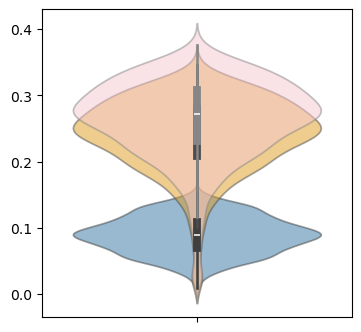

In [7]:
sns.violinplot(one_mse, alpha=0.5)
sns.violinplot(mean_mse, alpha=0.5, color="orange")
sns.violinplot(knn_mse, alpha=0.5, color="pink")

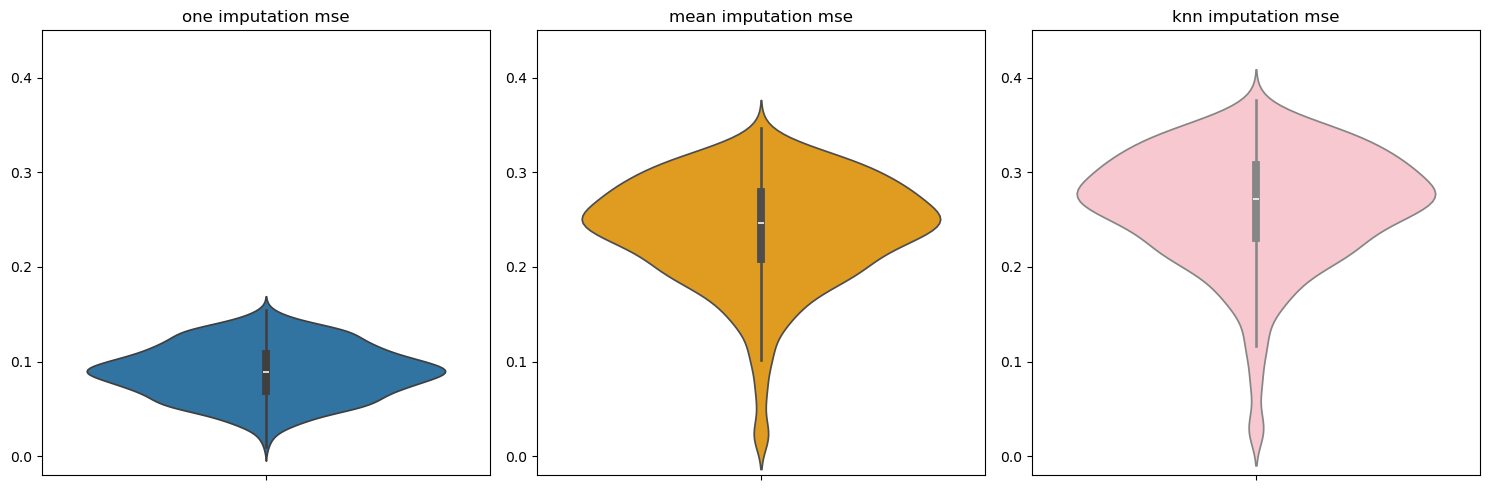

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.violinplot(one_mse, ax=axes[0])
axes[0].set_ylim(-0.02, 0.45)
axes[0].set_title("one imputation mse")

sns.violinplot(mean_mse, ax=axes[1], color="orange")
axes[1].set_ylim(-0.02, 0.45)
axes[1].set_title("mean imputation mse")

sns.violinplot(knn_mse, color="pink")
axes[2].set_ylim(-0.02, 0.45)
axes[2].set_title("knn imputation mse")

plt.tight_layout()
plt.show()